### Análise de Colaboradores (People Analytics)

In [1]:
# Importação do banco de dados:

import kagglehub

# Download latest version
path = kagglehub.dataset_download("anshika2301/hr-analytics-dataset")

print("Path to dataset files:", path)


c:\Users\lucas\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\lucas\.cache\kagglehub\datasets\anshika2301\hr-analytics-dataset\versions\1


In [2]:
import os 
import pandas as pd
import matplotlib.pyplot as plt

# Visualiazar o nome do arquivo:
os.listdir(path)


['HR Analytics Dashboard.pbix', 'HR_Analytics.csv']

In [3]:
# Banco de dados:
df = pd.read_csv(os.path.join(path,  'HR_Analytics.csv'))
df.head(10)


,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0
5,RM973,18,18-25,No,Non-Travel,1124,Research & Development,1,3,Life Sciences,...,3,80,0,0,5,4,0,0,0,0.0
6,RM1154,18,18-25,Yes,Travel_Frequently,544,Sales,3,2,Medical,...,3,80,0,0,2,4,0,0,0,0.0
7,RM1312,18,18-25,No,Non-Travel,1431,Research & Development,14,3,Medical,...,3,80,0,0,4,1,0,0,0,0.0
8,RM128,19,18-25,Yes,Travel_Rarely,528,Sales,22,1,Marketing,...,4,80,0,0,2,2,0,0,0,0.0
9,RM150,19,18-25,No,Travel_Rarely,1181,Research & Development,3,1,Medical,...,4,80,0,1,3,3,1,0,0,0.0


In [4]:
# Tamanho do dataset
print(f"Linhas: {df.shape[0]}, Colunas: {df.shape[1]}")

# Tipos de dados
print(df.dtypes)

# Valores nulos (%)
null_percent = (df.isnull().sum() / len(df)) * 100
print(null_percent.sort_values(ascending=False))
df


Linhas: 1480, Colunas: 38
EmpID                        object
Age                           int64
AgeGroup                     object
Attrition                    object
BusinessTravel               object
DailyRate                     int64
Department                   object
DistanceFromHome              int64
Education                     int64
EducationField               object
EmployeeCount                 int64
EmployeeNumber                int64
EnvironmentSatisfaction       int64
Gender                       object
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                      object
JobSatisfaction               int64
MaritalStatus                object
MonthlyIncome                 int64
SalarySlab                   object
MonthlyRate                   int64
NumCompaniesWorked            int64
Over18                       object
OverTime                     object
PercentSalaryHike             int64
Pe

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1475,RM412,60,55+,No,Travel_Rarely,422,Research & Development,7,3,Life Sciences,...,4,80,0,33,5,1,29,8,11,10.0
1476,RM428,60,55+,No,Travel_Frequently,1499,Sales,28,3,Marketing,...,4,80,0,22,5,4,18,13,13,11.0
1477,RM537,60,55+,No,Travel_Rarely,1179,Sales,16,4,Marketing,...,4,80,0,10,1,3,2,2,2,2.0
1478,RM880,60,55+,No,Travel_Rarely,696,Sales,7,4,Marketing,...,2,80,1,12,3,3,11,7,1,9.0


### Tratamento de valores nulos

In [5]:
# Remover colunas com mais de 40% de nulos
df = df.loc[:, null_percent < 40]

# Preencher valores categóricos
for col in df.select_dtypes(include='object'):   # Seleciona colunas do tipo object (categóricas)
    df[col] = df[col].fillna(df[col].mode()[0]) # Preenche os valores nulos com a moda (valor mais frequente) da coluna

# Preencher numéricos
for col in df.select_dtypes(include=['int64', 'float64']):  # Seleciona colunas do tipo int64 ou float64 (numéricas)
    df[col] = df[col].fillna(df[col].median()) # Preenche os valores nulos com a mediana da coluna

### Distribuição de colaboradores e análise inicial
A seguir, examinamos a distribuição dos colaboradores por departamento e por faixa etária para entender a composição do time antes de avançar para métricas de turnover.

,Colaboradores,Percentual (%)
Department,,
Research & Development,967,65.3
Sales,450,30.4
Human Resources,63,4.3


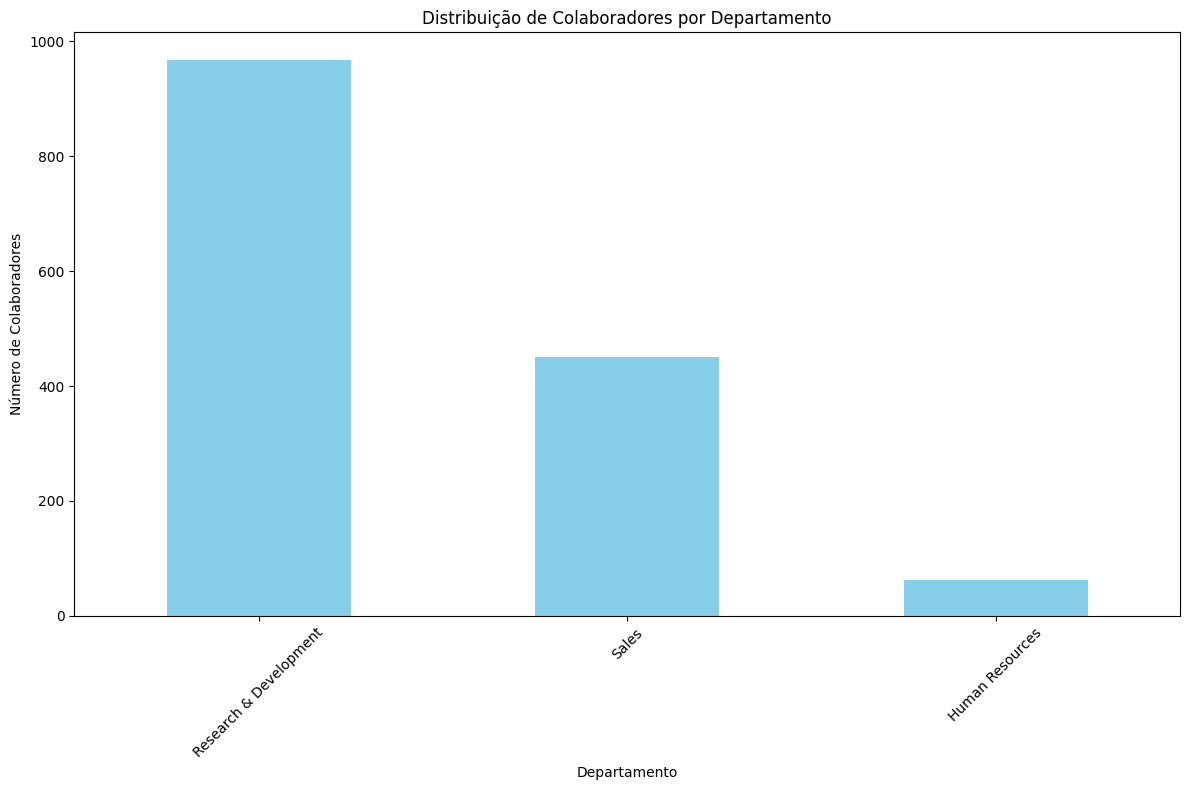

In [26]:
# Distribuição de colaboradores por departamento

department_counts = df['Department'].value_counts().sort_values(ascending=False)
department_pct = (department_counts / department_counts.sum() * 100).round(1)
department_summary = pd.DataFrame({
    'Colaboradores': department_counts,
    'Percentual (%)': department_pct
})
display(department_summary)

plt.figure(figsize=(12,8))
department_summary['Colaboradores'].plot(kind='bar', color='skyblue')
plt.title('Distribuição de Colaboradores por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Número de Colaboradores')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Colaboradores,Percentual (%)
AgeGroup,,
18-25,123,8.3
26-35,611,41.3
36-45,471,31.8
46-55,228,15.4
55+,47,3.2


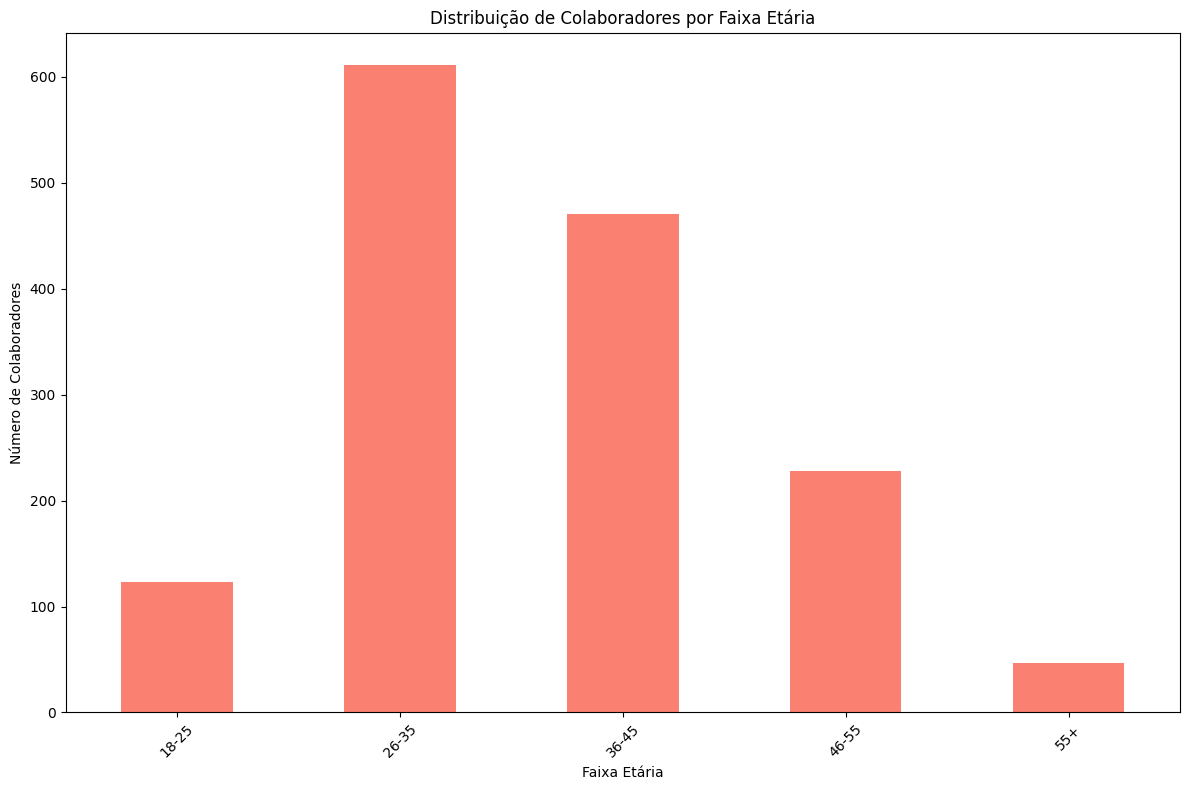

In [19]:
# Distribuição de colaboradores por faixa etária

age_counts = df['AgeGroup'].value_counts().sort_index()
age_pct = (age_counts / age_counts.sum() * 100).round(1)
age_summary = pd.DataFrame({
    'Colaboradores': age_counts,
    'Percentual (%)': age_pct
})
display(age_summary)

plt.figure(figsize=(12,8))
age_summary['Colaboradores'].plot(kind='bar', color='salmon')
plt.title('Distribuição de Colaboradores por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Número de Colaboradores')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Total,Saídas,Turnover (%)
Department,,,
Sales,450,93,20.67
Human Resources,63,12,19.05
Research & Development,967,133,13.75


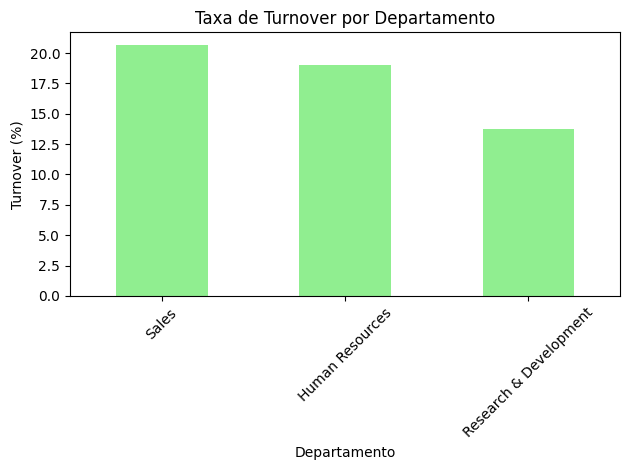

In [ ]:
# Turnover = Funcionários que saíram / Total de funcionários
# Análise de turnover por departamento

total_by_dept = df.groupby('Department').size()
attrition_by_dept = df[df['Attrition'] == 'Yes'].groupby('Department').size()
turnover_by_dept = (attrition_by_dept / total_by_dept).fillna(0).sort_values(ascending=False)

turnover_summary = pd.DataFrame({
    'Total': total_by_dept,
    'Saídas': attrition_by_dept,
    'Turnover (%)': (turnover_by_dept * 100).round(2) 
}).fillna(0).sort_values('Turnover (%)', ascending=False)

display(turnover_summary)

plt.figure(figsize=(12,8))
turnover_summary['Turnover (%)'].plot(kind='bar', color='lightgreen')
plt.title('Taxa de Turnover por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Turnover (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Total,Saídas,Turnover (%)
YearsAtCompany,,,
0,44,16,36.36
1,171,59,34.50
2,127,27,21.26
3,129,21,16.28
4,112,19,16.96
5,198,21,10.61
6,77,9,11.69
7,91,11,12.09
8,80,9,11.25


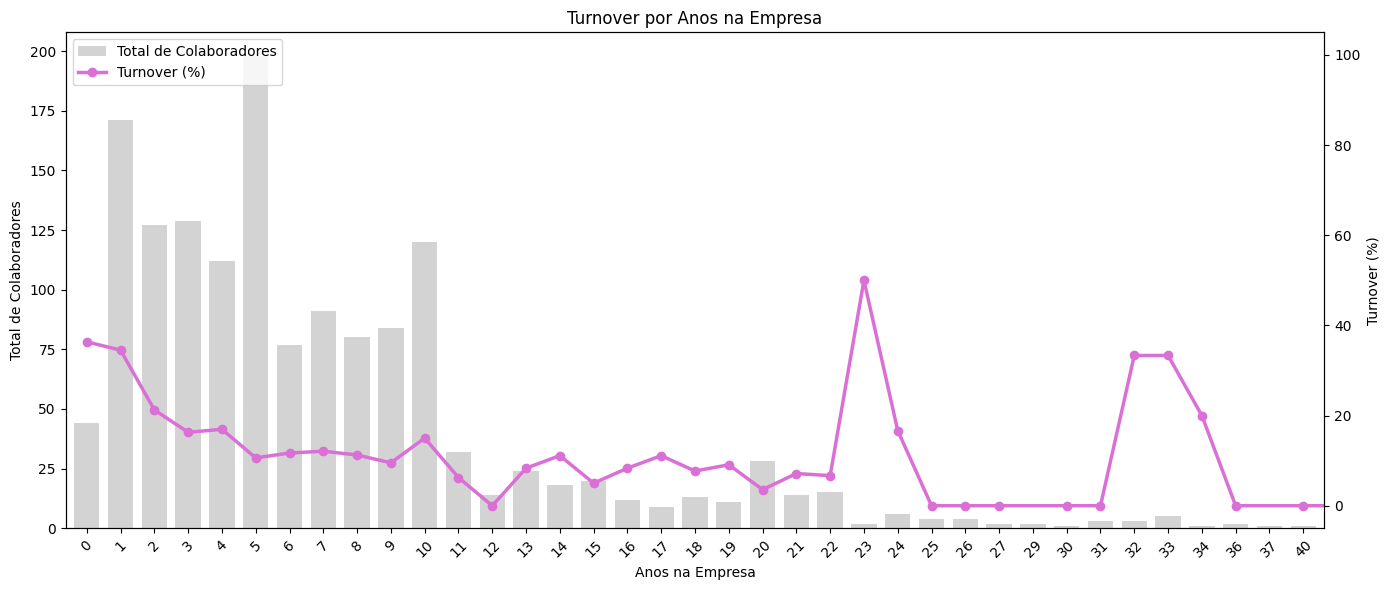

In [30]:
# Análise de turnover por tempo de empresa (YearsAtCompany)

years_summary = df.groupby('YearsAtCompany').agg(
    Total=('Attrition', 'size'),
    Saídas=('Attrition', lambda x: (x == 'Yes').sum())
)
years_summary['Turnover (%)'] = (years_summary['Saídas'] / years_summary['Total'] * 100).round(2)
years_summary = years_summary.sort_index()

display(years_summary)

fig, ax1 = plt.subplots(figsize=(14,6))
years_summary['Total'].plot(kind='bar', color='lightgray', ax=ax1, width=0.75, label='Total de Colaboradores')
ax2 = ax1.twinx()
years_summary['Turnover (%)'].plot(kind='line', marker='o', color='orchid', linewidth=2.5, ax=ax2, label='Turnover (%)')

ax1.set_xlabel('Anos na Empresa')
ax1.set_ylabel('Total de Colaboradores')
ax2.set_ylabel('Turnover (%)')
ax1.set_title('Turnover por Anos na Empresa')
ax1.set_xticklabels(years_summary.index.astype(str), rotation=45)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')
plt.tight_layout()
plt.show()

### Insight 

A partir dessa análise, o principal foco deve ser identificar se o turnover está concentrado em colaboradores com pouco tempo de empresa ou em profissionais que já estão há alguns anos.

- Uma alta taxa em `1-2 anos` sugere problemas de integração, contratação ou expectativas desalinhadas.
- Um pico em `3-5 anos` sugere que a retenção está sendo afetada pela falta de plano de carreira, promoção ou reconhecimento.
- Para validar e aprofundar, combine essa análise com `JobSatisfaction`, `YearsSinceLastPromotion` e `PerformanceRating`.

Este tipo de insight é típico de uma análise de RH com foco em retenção: não basta apontar o turnover, é preciso indicar onde a empresa deve priorizar ações.

,IncomeBand,Total,Saídas,Turnover (%)
0,0-2k,33,18,54.55
1,2k-4k,513,119,23.20
2,4k-6k,373,42,11.26
3,6k-8k,176,18,10.23
4,8k-10k,102,15,14.71
5,10k-12k,87,15,17.24
6,12k-14k,54,6,11.11
7,14k-16k,16,0,0.00
8,16k+,126,5,3.97


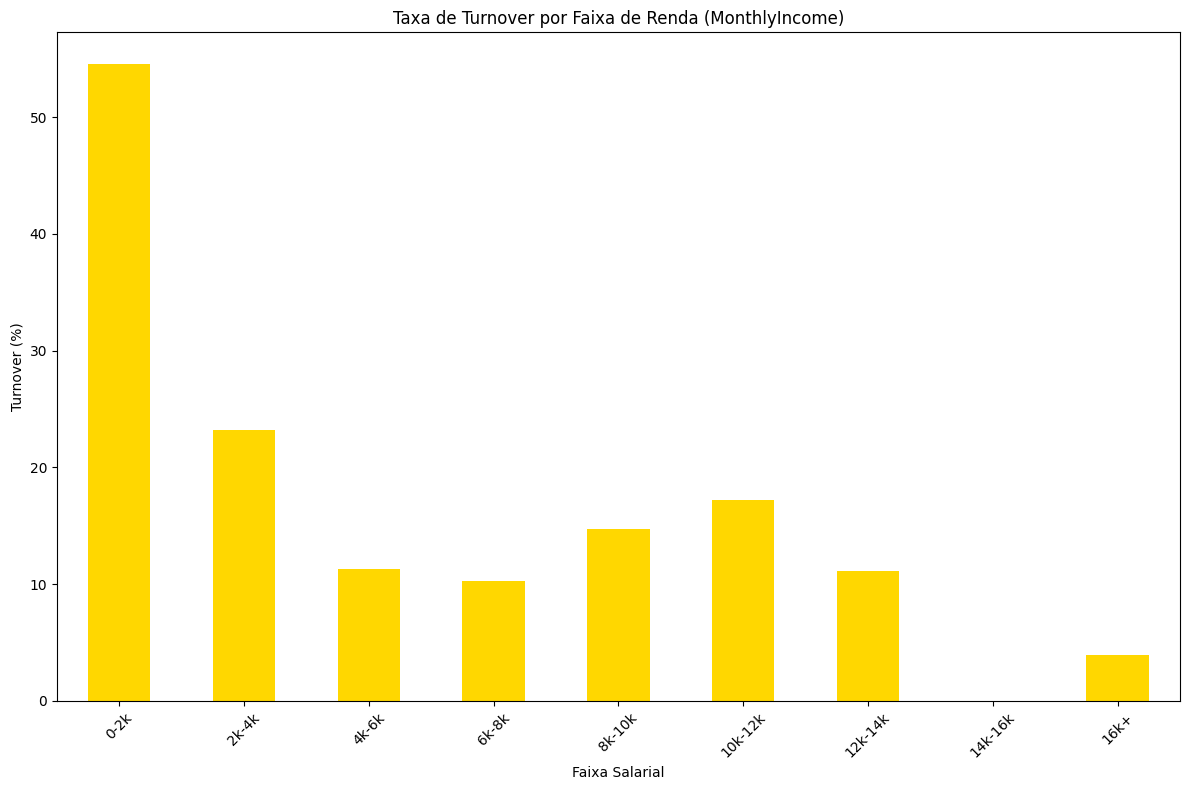

In [36]:
# Salário X saída (Attrition) - usando faixas de MonthlyIncome para um agrupamento mais útil

salary_bins = [0, 2000, 4000, 6000, 8000, 10000, 12000, 14000, 16000, 20000]
labels = ['0-2k', '2k-4k', '4k-6k', '6k-8k', '8k-10k', '10k-12k', '12k-14k', '14k-16k', '16k+']
df['IncomeBand'] = pd.cut(df['MonthlyIncome'], bins=salary_bins, labels=labels, include_lowest=True)

salary_summary = df.groupby('IncomeBand', observed=False).agg(
    Total=('Attrition', 'size'),
    Saídas=('Attrition', lambda x: (x == 'Yes').sum())
)
salary_summary['Turnover (%)'] = (salary_summary['Saídas'] / salary_summary['Total'] * 100).round(2)
salary_summary = salary_summary.reset_index()

display(salary_summary)

plt.figure(figsize=(12,8))
salary_summary.set_index('IncomeBand')['Turnover (%)'].plot(kind='bar', color='gold')
plt.title('Taxa de Turnover por Faixa de Renda (MonthlyIncome)')
plt.xlabel('Faixa Salarial')
plt.ylabel('Turnover (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Recomendações Estratégicas:

Revisão Urgente na Base: Investigar se o turnover de 54,55% na faixa 0-2k é causado por salário abaixo do mercado, falta de benefícios ou condições de trabalho exaustivas. O custo de contratar e treinar novos funcionários nessa faixa pode estar saindo mais caro que um ajuste salarial.

Plano de Retenção para Mid-Level: Criar incentivos ou planos de carreira mais claros para quem ganha entre 8k e 12k, para evitar a perda de talentos experientes que já conhecem a operação da empresa.

Manutenção do Topo: Entender o que está funcionando nas faixas acima de 14k e tentar replicar a cultura ou os benefícios (proporcionalmente) para as faixas imediatamente inferiores.